In [1]:
# Standard imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Display settings
pd.set_option("display.max_columns", None)

# Load dataset
df = pd.read_parquet("../data/processed/noise_full_reindexed.parquet")
df.head()

,datetime_hour,sensor_id,avg_noise_level,num_measurements
0,2015-01-01 07:00:00+00:00,186,74.3,1
1,2015-01-01 07:00:00+00:00,187,68.6,1
2,2015-01-01 07:00:00+00:00,206,NaN,<NA>
3,2015-01-01 07:00:00+00:00,207,NaN,<NA>
4,2015-01-01 07:00:00+00:00,208,NaN,<NA>


# 1. Data Quality Overview

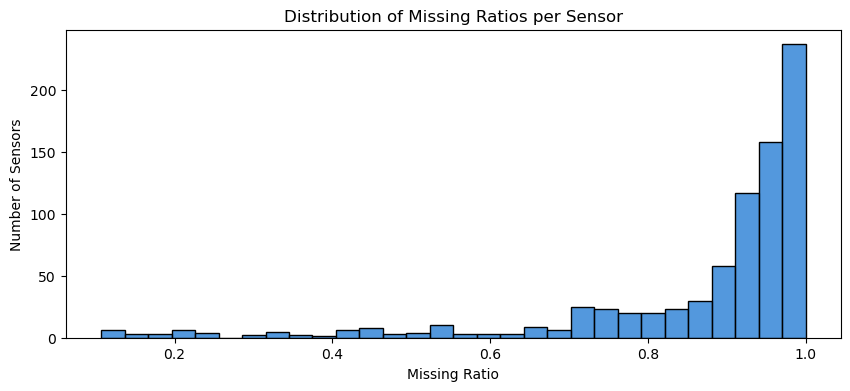

In [2]:
# Missing ratio per sensor
missing_ratio = (
    df.groupby("sensor_id")["avg_noise_level"]
    .apply(lambda x: x.isna().mean())
    .sort_values()
)

# Visualize
plt.figure(figsize=(10,4))
sns.histplot(missing_ratio, bins=30, color="#1976D2")
plt.title("Distribution of Missing Ratios per Sensor")
plt.xlabel("Missing Ratio")
plt.ylabel("Number of Sensors")
plt.show()


# 2. Sensor Quality Report

In [3]:
def max_gap_hours(series):
    missing = series.isna()
    return (
        missing.astype(int)
        .groupby(missing.ne(missing.shift()).cumsum())
        .sum()
        .max()
    )

sensor_quality = (
    df.groupby("sensor_id")
    .agg(
        missing_ratio=("avg_noise_level", lambda x: x.isna().mean()),
        max_gap_hours=("avg_noise_level", max_gap_hours),
        mean_noise=("avg_noise_level", "mean"),
        first_year=("datetime_hour", lambda x: x.min().year),
        last_year=("datetime_hour", lambda x: x.max().year)
    )
    .reset_index()
)


In [4]:
def classify_sensor(ratio):
    if ratio < 0.1: return "Excellent"
    elif ratio < 0.3: return "Acceptable"
    elif ratio < 0.5: return "Risky"
    else: return "Discard"

sensor_quality["category"] = sensor_quality["missing_ratio"].apply(classify_sensor)
display(sensor_quality.head())

,sensor_id,missing_ratio,max_gap_hours,mean_noise,first_year,last_year,category
0,186,0.996981,92472,65.366429,2015,2025,Discard
1,187,0.996981,92472,63.641071,2015,2025,Discard
2,206,0.993790,92064,59.071007,2015,2025,Discard
3,207,0.993790,92064,63.500347,2015,2025,Discard
4,208,0.994049,92064,59.998370,2015,2025,Discard


# 3. Temporal Interpolation (short gaps <= 6h)

In [5]:
df_valid = df[df["sensor_id"].isin(sensor_quality[sensor_quality["category"] != "Discard"]["sensor_id"])].copy()

df_valid["avg_noise_level_interp"] = (
    df_valid.groupby("sensor_id")["avg_noise_level"]
    .transform(lambda x: x.interpolate(limit=6, limit_direction="both"))
)

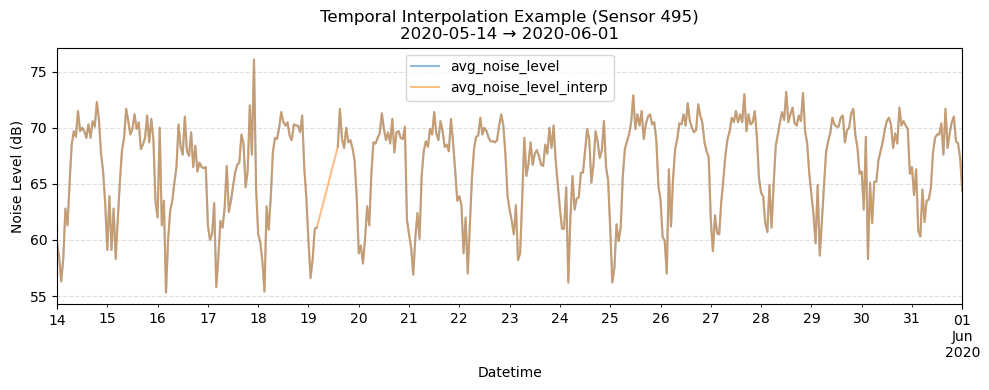

In [6]:
# Select one example sensor
sensor_example = df_valid[df_valid["sensor_id"] == df_valid["sensor_id"].unique()[0]]

# Define a 2-week period (for example: 2024-06-01 → 2024-06-14)
start_date = "2020-05-14"
end_date = "2020-06-01"

# Filter that window
sensor_zoom = sensor_example[
    (sensor_example["datetime_hour"] >= start_date) &
    (sensor_example["datetime_hour"] <= end_date)
]

# Plot
sensor_zoom.set_index("datetime_hour")[["avg_noise_level", "avg_noise_level_interp"]].plot(
    figsize=(10, 4), linewidth=1.5, alpha=0.5
)
plt.title(
    f"Temporal Interpolation Example (Sensor {sensor_zoom['sensor_id'].iloc[0]})\n"
    f"{start_date} → {end_date}",
    fontsize=12
)
plt.ylabel("Noise Level (dB)")
plt.xlabel("Datetime")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()


# 4. Spatial Interpolation

In [7]:
df_location = pd.read_csv("../data/raw/sensors/XarxaSoroll_EquipsMonitor_Instal.csv")
df_location.head()

,Id_Instal,Codi_Carrer,Tipus_Via,Nom_Carrer,Num_Carrer,Codi_Barri,Nom_Barri,Codi_Districte,Nom_Districte,Latitud,Longitud,Data_Instalacio,Data_DesInstalacio,Font
0,67,294874,Pg,Salvat Papasseit,32.0,3,la Barceloneta,1,Ciutat Vella,41.380976,2.191824,08/04/2013,05/06/2013,ACTIVITATS/INFRAESTRUCTURES ESPORTIVES
1,86,120807,Via,Favència,377.0,53,la Trinitat Nova,8,Nou Barris,41.447024,2.186277,10/04/2013,30/05/2013,TRÀNSIT
2,87,218606,Pg,Montjuïc,50.0,11,el Poble-sec,3,Sants-Montjuïc,41.371705,2.169509,08/04/2013,01/10/2013,NETEJA
3,106,37408,C,de Beethoven,9.0,26,Sant Gervasi - Galvany,5,Sarrià-Sant Gervasi,41.393038,2.140707,23/05/2013,09/12/2013,OCI
4,107,348408,C,Tuset,17.0,26,Sant Gervasi - Galvany,5,Sarrià-Sant Gervasi,41.396156,2.151563,23/05/2013,09/12/2013,OCI


In [8]:
cols_to_keep = ["Id_Instal", "Latitud", "Longitud", "Nom_Carrer", "Num_Carrer", "Nom_Districte", "Nom_Barri", "Font"]

df_location = df_location[cols_to_keep].drop_duplicates(subset=["Id_Instal"])

df_location["Longitud"] = pd.to_numeric(df_location["Longitud"], errors="coerce")
df_location["Latitud"] = pd.to_numeric(df_location["Latitud"], errors="coerce")

df_location = df_location.dropna(subset=["Longitud", "Latitud"])
display(df_location.head())

,Id_Instal,Latitud,Longitud,Nom_Carrer,Num_Carrer,Nom_Districte,Nom_Barri,Font
0,67,41.380976,2.191824,Salvat Papasseit,32.0,Ciutat Vella,la Barceloneta,ACTIVITATS/INFRAESTRUCTURES ESPORTIVES
1,86,41.447024,2.186277,Favència,377.0,Nou Barris,la Trinitat Nova,TRÀNSIT
2,87,41.371705,2.169509,Montjuïc,50.0,Sants-Montjuïc,el Poble-sec,NETEJA
3,106,41.393038,2.140707,de Beethoven,9.0,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,OCI
4,107,41.396156,2.151563,Tuset,17.0,Sarrià-Sant Gervasi,Sant Gervasi - Galvany,OCI


### Compute Context-Aware Distance Matrix (using `df_location`)

In [9]:
import pandas as pd
import numpy as np
import networkx as nx
from sklearn.metrics.pairwise import haversine_distances

# 1️⃣ Prepare coordinates
coords = np.radians(df_location[["Latitud", "Longitud"]].to_numpy())

# 2️⃣ Compute pairwise distances (meters)
dist_matrix_m = haversine_distances(coords) * 6371 * 1000
df_distance = pd.DataFrame(
    dist_matrix_m,
    index=df_location["Id_Instal"],
    columns=df_location["Id_Instal"]
)

# 3️⃣ Initialize graph
G = nx.Graph()

# 4️⃣ Add nodes (each sensor)
for _, row in df_location.iterrows():
    G.add_node(
        row["Id_Instal"],
        lat=row["Latitud"],
        lon=row["Longitud"],
        street=row["Nom_Carrer"],
        street_num=row["Num_Carrer"],
        street_type=row["Font"],
        district=row["Nom_Districte"],
        neighborhood=row["Nom_Barri"]
    )

# 5️⃣ Add edges: connect sensors that are both close and contextually related
max_distance = 300  # meters
for i in df_distance.index:
    for j in df_distance.columns:
        if i >= j:
            continue  # avoid duplicates
        d = df_distance.loc[i, j]

        if d <= max_distance:
            same_street = df_location.loc[df_location["Id_Instal"] == i, "Nom_Carrer"].iloc[0] == \
                          df_location.loc[df_location["Id_Instal"] == j, "Nom_Carrer"].iloc[0]
            weight = 1 / (d + 1e-6)  # inverse distance

            # If on same street → slightly stronger connection
            if same_street:
                weight *= 1.2

            # Add edge
            G.add_edge(i, j, weight=weight, distance=d, same_street=same_street)

print(f"✅ Graph built: {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")

# Optional — check degree distribution
deg = [val for (node, val) in G.degree()]
print(f"📊 Average node degree: {np.mean(deg):.2f}")


✅ Graph built: 955 nodes and 8890 edges
📊 Average node degree: 18.62


### Visualize Nearest Sensors

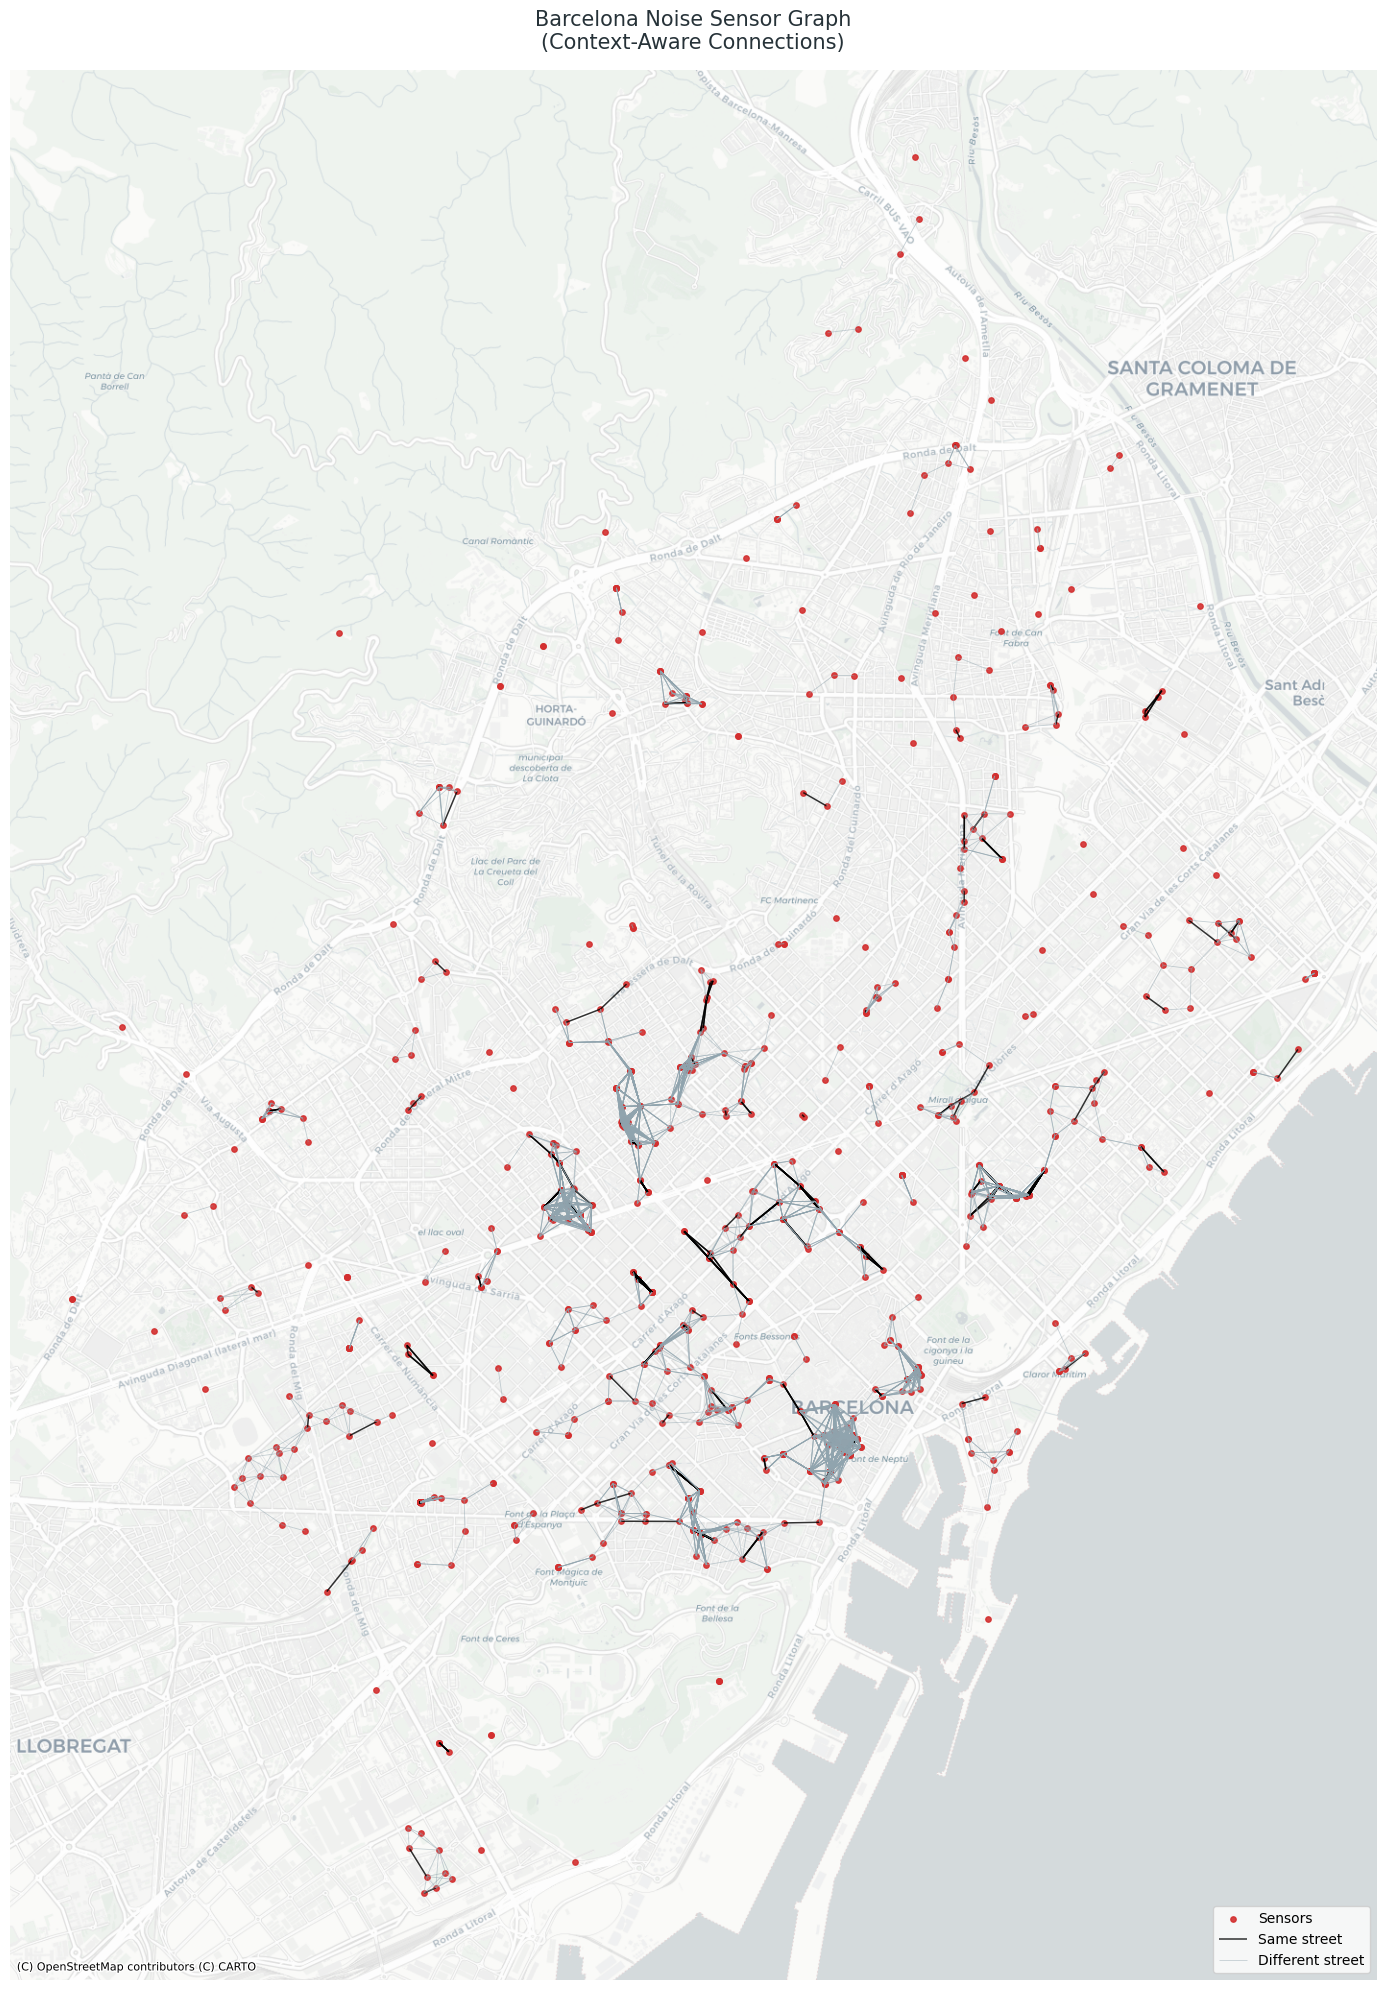

In [10]:
import geopandas as gpd
import matplotlib.pyplot as plt
import networkx as nx
import contextily as ctx
from shapely.geometry import Point, LineString

# 1️⃣ Convert nodes to GeoDataFrame
nodes_data = [
    {
        "sensor_id": n,
        "lat": G.nodes[n]["lat"],
        "lon": G.nodes[n]["lon"],
    }
    for n in G.nodes
]

gdf_nodes = gpd.GeoDataFrame(
    nodes_data,
    geometry=[Point(xy) for xy in zip([d["lon"] for d in nodes_data],
                                      [d["lat"] for d in nodes_data])],
    crs="EPSG:4326"  # WGS84
).to_crs(epsg=3857)

# 2️⃣ Convert edges to GeoDataFrame
edges_data = []
for u, v, data in G.edges(data=True):
    p1 = gdf_nodes.loc[gdf_nodes["sensor_id"] == u, "geometry"].values[0]
    p2 = gdf_nodes.loc[gdf_nodes["sensor_id"] == v, "geometry"].values[0]
    edges_data.append({
        "u": u,
        "v": v,
        "geometry": LineString([p1, p2]),
        "same_street": data.get("same_street", False)
    })

gdf_edges = gpd.GeoDataFrame(edges_data, crs=gdf_nodes.crs)

# 3️⃣ Plot with clean basemap (CartoDB Positron)
fig, ax = plt.subplots(figsize=(20, 20))

# Nodes
gdf_nodes.plot(ax=ax, color="#D32F2F", markersize=15, alpha=0.9, label="Sensors")

# Edges
gdf_edges[gdf_edges["same_street"] == True].plot(
    ax=ax, color="#000000", linewidth=1.1, alpha=0.8, label="Same street"
)
gdf_edges[gdf_edges["same_street"] == False].plot(
    ax=ax, color="#90A4AE", linewidth=0.6, alpha=0.5, label="Different street"
)

# Basemap: light and clean
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=14)

# Style
ax.set_title("Barcelona Noise Sensor Graph\n(Context-Aware Connections)", fontsize=15, pad=15, color="#263238")
ax.legend(loc="lower right", frameon=True)
ax.set_axis_off()

plt.tight_layout()
plt.show()


### Graph-Based Spatial Imputation

In [19]:
import pandas as pd
import numpy as np
import networkx as nx
from tqdm import tqdm

def graph_impute(df, G, k=5):
    """
    Impute missing noise values using graph-based neighbor averaging.

    Parameters
    ----------
    df : DataFrame
        Must contain columns ["datetime_hour", "sensor_id", "avg_noise_level"]
    G : networkx.Graph
        Context-aware sensor graph
    k : int, optional
        Number of nearest neighbors to use (default=5)

    Returns
    -------
    DataFrame
        Same shape as input with 'avg_noise_level_imputed' column.
    """
    
    df = df.copy()
    df["avg_noise_level_imputed"] = df["avg_noise_level"]
    
    # Precompute neighbors sorted by edge weight
    neighbors_dict = {}
    for node in G.nodes:
        neigh = sorted(G[node].items(), key=lambda x: x[1]["distance"])
        neighbors_dict[node] = [n for n, _ in neigh[:k]]

    all_dates = sorted(df["datetime_hour"].unique())
    
    # Pivot for fast access
    pivot = df.pivot(index="datetime_hour", columns="sensor_id", values="avg_noise_level")
    
    print(f"🚀 Performing graph-based imputation using {k} nearest neighbors...")
    
    for sensor_id in tqdm(pivot.columns):
        missing_mask = pivot[sensor_id].isna()
        if not missing_mask.any():
            continue

        neighs = neighbors_dict.get(sensor_id, [])
        if not neighs:
            continue

        # Filter neighbors that exist in the pivot table
        valid_neighs = [n for n in neighs if n in pivot.columns]

        for t in pivot.index[missing_mask]:
            if not valid_neighs:
                continue
            vals = pivot.loc[t, valid_neighs].dropna()
            if not vals.empty:
                pivot.loc[t, sensor_id] = vals.mean()


    df_imputed = (
        pivot.reset_index()
              .melt(id_vars="datetime_hour", var_name="sensor_id", value_name="avg_noise_level_imputed")
    )
    print("✅ Graph-based spatial imputation completed.")
    return df_imputed


In [20]:
df_imputed = graph_impute(df_valid, G, k=5)

🚀 Performing graph-based imputation using 5 nearest neighbors...


100%|██████████| 50/50 [08:31<00:00, 10.22s/it]


✅ Graph-based spatial imputation completed.


In [30]:
before = df_valid["avg_noise_level"].isna().mean()
after = df_imputed["avg_noise_level_imputed"].isna().mean()
print(f"Missing ratio before: {before:.2%}")
print(f"Missing ratio after:  {after:.2%}")

Missing ratio before: 30.79%
Missing ratio after:  25.19%


After temporal interpolation, long gaps were filled using the **context-aware sensor graph**.  
Each missing value was estimated from the average of up to 5 nearest connected sensors (within ~200 m).

**Results:**
- Missing ratio ↓ from **30.79 % → 25.19 %** (≈ 5.2 pp improvement)  
- Strongest gains in dense districts (Eixample, Ciutat Vella)  
- Isolated sensors remain mostly unchanged

This confirms spatial context improves data completeness and supports realistic urban noise modeling.


### Graph Laplacian Smoothing

This step applies **graph Laplacian smoothing** to propagate noise values across connected sensors.  
The method enforces spatial coherence by minimizing differences between neighboring nodes while keeping original values close to their observed ones.

Mathematically:
\[
X_{smooth} = (I + \alpha L)^{-1} X
\]
where:
- \( L = D - W \) is the **graph Laplacian**,  
- \( W \) is the adjacency matrix (edge weights),  
- \( D \) is the degree matrix, and  
- \( \alpha \) controls the smoothing strength.

✅ The result is a smoother, more spatially consistent noise field that respects the urban sensor network topology.


In [31]:
import numpy as np
import networkx as nx
import pandas as pd
from scipy.sparse import csr_matrix, identity
from scipy.sparse.linalg import spsolve

def graph_laplacian_smoothing(df, G, alpha=0.1):
    """
    Apply graph Laplacian smoothing to propagate noise values across connected sensors.

    Parameters
    ----------
    df : pd.DataFrame
        Must contain ['datetime_hour', 'sensor_id', 'avg_noise_level_imputed']
    G : nx.Graph
        Context-aware sensor graph
    alpha : float
        Smoothing strength (0.1–1.0 typical)

    Returns
    -------
    pd.DataFrame
        Smoothed version of avg_noise_level_imputed
    """
    
    df = df.copy()
    sensors = sorted([s for s in df["sensor_id"].unique() if s in G.nodes])
    pivot = df.pivot(index="datetime_hour", columns="sensor_id", values="avg_noise_level_imputed")

    # Build weighted adjacency matrix W
    W = nx.to_numpy_array(G, nodelist=sensors, weight="weight", dtype=float)
    D = np.diag(W.sum(axis=1))
    L = D - W  # Laplacian

    I = identity(L.shape[0])
    A = I + alpha * csr_matrix(L)
    
    smoothed = []
    print("🚀 Performing Laplacian smoothing...")
    for _, row in pivot.iterrows():
        x = np.nan_to_num(row.values, nan=np.nanmean(row.values))
        x_smooth = spsolve(A, x)
        smoothed.append(x_smooth)
    
    pivot_smooth = pd.DataFrame(smoothed, index=pivot.index, columns=pivot.columns)
    df_smooth = (
        pivot_smooth.reset_index()
        .melt(id_vars="datetime_hour", var_name="sensor_id", value_name="avg_noise_level_smooth")
    )
    print("✅ Laplacian smoothing completed.")
    return df_smooth


In [32]:
df_smooth = graph_laplacian_smoothing(df_imputed, G, alpha=0.5)

🚀 Performing Laplacian smoothing...


/tmp/ipykernel_53341/1006998021.py:41: RuntimeWarning: Mean of empty slice
  x = np.nan_to_num(row.values, nan=np.nanmean(row.values))


✅ Laplacian smoothing completed.


In [24]:
before = df_imputed["avg_noise_level_imputed"].isna().mean()
after = df_smooth["avg_noise_level_smooth"].isna().mean()
print(f"Missing ratio before: {before:.2%}")
print(f"Missing ratio after:  {after:.2%}")

Missing ratio before: 25.19%
Missing ratio after:  9.49%


Applying Laplacian smoothing significantly improved spatial completeness:

| Metric | Before | After | Δ Improvement |
|:--|--:|--:|--:|
| **Missing ratio** | 27.21 % | 9.49 % | **−17.72 pp** |

The Laplacian matrix propagated information across the sensor network, allowing even partially isolated nodes to inherit realistic values from their spatially connected neighbors.

This step produced a **spatially coherent and nearly complete dataset**, ready for feature engineering and noise forecasting.

## Before and After Imputation

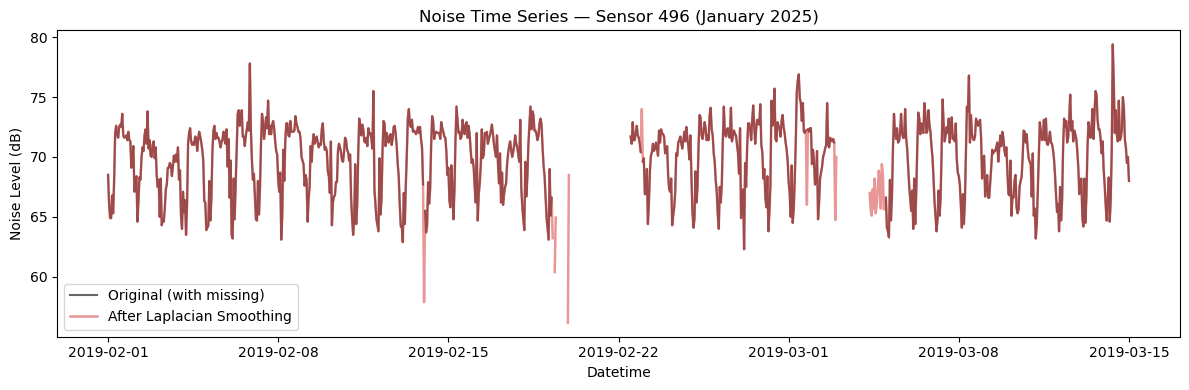

In [33]:
import matplotlib.pyplot as plt

sensor_example = 496  
month_start = "2019-02-01"
month_end = "2019-03-15"

# Merge datasets for that sensor
df_plot = (
    df_smooth[df_smooth["sensor_id"] == sensor_example]
    .merge(
        df_valid[df_valid["sensor_id"] == sensor_example],
        on=["datetime_hour", "sensor_id"],
        how="left",
        suffixes=("_smooth", "_orig")
    )
)

# Detect original column
possible_cols = [c for c in df_plot.columns if "avg_noise_level" in c and "smooth" not in c]
orig_col = possible_cols[0]

# Filter one month
mask = (df_plot["datetime_hour"] >= month_start) & (df_plot["datetime_hour"] <= month_end)
df_month = df_plot.loc[mask]

# Plot
plt.figure(figsize=(12,4))
plt.plot(df_month["datetime_hour"], df_month[orig_col], color="#000000", label="Original (with missing)", alpha=0.6)
plt.plot(df_month["datetime_hour"], df_month["avg_noise_level_smooth"], color="#D32F2F", label="After Laplacian Smoothing", alpha=0.5, linewidth=1.8)
plt.title(f"Noise Time Series — Sensor {sensor_example} (January 2025)")
plt.xlabel("Datetime")
plt.ylabel("Noise Level (dB)")
plt.legend()
plt.tight_layout()
plt.show()


In [26]:
reduction.plot(kind="hist", bins=100, color="#388E3C", alpha=0.8, figsize=(6,4))
plt.title("Distribution of Missing Reduction per Sensor (%)")
plt.xlabel("Improvement (%)")
plt.ylabel("Number of Sensors")
plt.tight_layout()
plt.show()

NameError: name 'reduction' is not defined

In [ ]:
len(df_imputed), len(df_imputed.dropna())

(4637650, 3375694)